<a href="https://colab.research.google.com/github/SirLousy/LIS4693/blob/main/lab-5/lab_assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/SirLousy/LIS4693/refs/heads/main/lab-5/lens-export.csv"
df = pd.read_csv(url)

df.head()

,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-061-210-458-474,Cybersecurity and Communication,2019-06-10,2019,book chapter,The Handbook of Communication and Security,NaN,Routledge,NaN,Sean Lawson; Michael K. Middleton,...,NaN,10.4324/9781351180962-16,2.951110e+09,NaN,0,012-724-957-779-25X,1,False,NaN,NaN
1,000-639-133-502-299,End-Users vs Software Practitioners: Recruitme...,2024-09-02,2024,conference proceedings article,2024 IEEE Symposium on Visual Languages and Hu...,NaN,IEEE,NaN,Wei Wang; Dulaji Hidellaarachchi; John Grundy;...,...,NaN,10.1109/vl/hcc60511.2024.00063,NaN,NaN,0,000-226-864-656-026; 000-818-130-729-838; 000-...,1,False,NaN,NaN
2,000-681-441-330-07X,Security Assessment of IC Packaging Against Op...,2021-05-01,2021,journal article,EDFA Technical Articles,15370755,ASM International,United States,Chengjie Xi; Aslam A. Khan; M. Tanjidur Rahman...,...,NaN,10.31399/asm.edfa.2021-2.p004,NaN,NaN,0,NaN,1,False,NaN,NaN
3,000-853-474-479-303,"Limitations, Objections, and the Future of the...",2017-06-22,2017,book,Oxford Scholarship Online,NaN,Oxford University Press,NaN,Ben Buchanan,...,NaN,10.1093/acprof:oso/9780190665012.003.0008,NaN,NaN,0,NaN,0,False,NaN,NaN
4,001-012-590-807-693,Antecedents and Consequences of Cybersecurity ...,NaN,2019,journal article,Journal of ETA Maritime Science,21472955; 21489386,Galenos Yayinevi,NaN,Pelin Bolat; Gizem Kayisoglu,...,NaN,10.5505/jems.2019.85057,2.997233e+09,NaN,0,091-511-454-565-387,15,True,cc-by-nc,gold


## Task 1

I collected over 1000 research articles from Lens.org using the search query "cybersecurity". The dataset includes bibliographic metadata such as titles, abstracts, authors, and publication information. I selected this dataset because cybersecurity is an important and rapidly growing field that affects organizations, governments, and individuals. Analyzing research in this area can help identify common themes such as vulnerabilities, protection methods, and emerging technologies.

In [2]:
df.head(10)

texts = df['Abstract'].dropna()

In [3]:
!pip install gensim nltk

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Task 2

I displayed the first 10 rows of the dataset to examine its structure and available columns. I selected the Abstract column for topic modeling because it contains more detailed information about each article than the title alone. Since topic modeling works better with richer text, the abstracts provide more context and make it easier to identify meaningful themes across the dataset.

In [4]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

custom_stopwords = {'et', 'al', 'study', 'result', 'using', 'data', 'paper', 'research'}
stop_words.update(custom_stopwords)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words and len(word) > 2 and not word.isnumeric()]

    return tokens

processed_texts = [preprocess(text) for text in texts]

In [5]:
processed_texts = [preprocess(text) for text in texts]

## Preprocessing

Before building the topic models, I cleaned and preprocessed the text data. This included converting text to lowercase, removing punctuation, tokenizing the words, removing common stopwords, removing numbers, and filtering out very short words. I also added custom stopwords such as "study," "research," and "paper" because they appeared often but did not add meaningful topic information. This step helps improve the quality and interpretability of the topics.

In [6]:
from gensim import corpora

dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]

In [7]:
from gensim.models import LdaModel

lda_10 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=10, passes=10, random_state=42)
lda_20 = LdaModel(corpus=corpus, id2word=dictionary, num_topics=20, passes=10, random_state=42)

In [8]:
print("LDA with 10 topics")
for i, topic in lda_10.print_topics(num_words=5):
    print(f"Topic {i}: {topic}")

LDA with 10 topics
Topic 0: 0.066*"cybersecurity" + 0.011*"framework" + 0.010*"governance" + 0.009*"cyber" + 0.008*"risk"
Topic 1: 0.064*"cybersecurity" + 0.009*"security" + 0.007*"risk" + 0.007*"management" + 0.006*"strong"
Topic 2: 0.058*"cybersecurity" + 0.012*"national" + 0.007*"system" + 0.007*"critical" + 0.006*"development"
Topic 3: 0.056*"cybersecurity" + 0.028*"jats" + 0.010*"title" + 0.010*"information" + 0.009*"sec"
Topic 4: 0.063*"cybersecurity" + 0.015*"training" + 0.009*"exam" + 0.009*"framework" + 0.009*"architect"
Topic 5: 0.072*"cybersecurity" + 0.009*"security" + 0.009*"cyber" + 0.007*"national" + 0.007*"information"
Topic 6: 0.016*"security" + 0.013*"software" + 0.011*"cybersecurity" + 0.007*"development" + 0.006*"user"
Topic 7: 0.076*"cybersecurity" + 0.005*"skills" + 0.005*"professionals" + 0.005*"education" + 0.005*"technical"
Topic 8: 0.070*"cybersecurity" + 0.021*"students" + 0.013*"education" + 0.010*"learning" + 0.008*"awareness"
Topic 9: 0.078*"cybersecurity"

In [9]:
print("\nLDA with 20 topics")
for i, topic in lda_20.print_topics(num_words=5):
    print(f"Topic {i}: {topic}")


LDA with 20 topics
Topic 0: 0.063*"cybersecurity" + 0.016*"risk" + 0.015*"governance" + 0.010*"management" + 0.008*"cyber"
Topic 1: 0.056*"cybersecurity" + 0.009*"software" + 0.008*"strong" + 0.007*"development" + 0.007*"management"
Topic 2: 0.057*"cybersecurity" + 0.011*"national" + 0.008*"information" + 0.006*"cyber" + 0.006*"digital"
Topic 3: 0.057*"cybersecurity" + 0.010*"jats" + 0.010*"information" + 0.008*"companies" + 0.008*"services"
Topic 4: 0.051*"cybersecurity" + 0.010*"requirements" + 0.010*"framework" + 0.009*"threats" + 0.009*"nist"
Topic 5: 0.069*"cybersecurity" + 0.015*"education" + 0.006*"cyber" + 0.006*"development" + 0.006*"sector"
Topic 6: 0.015*"security" + 0.012*"cybersecurity" + 0.010*"challenges" + 0.009*"genomic" + 0.007*"training"
Topic 7: 0.080*"cybersecurity" + 0.008*"skills" + 0.006*"professionals" + 0.006*"jats" + 0.005*"technical"
Topic 8: 0.077*"cybersecurity" + 0.029*"students" + 0.023*"education" + 0.012*"learning" + 0.011*"workforce"
Topic 9: 0.079*"

## Task 3

I ran two LDA topic models, one with 10 topics and one with 20 topics, and compared the top 5 words in each topic. The 10 topic model produced broader and more general themes, while the 20 topic model created more specific topics but also showed more overlap between some of them. Overall, the 10 topic model was more interpretable because the topics were clearer and easier to distinguish.

In [10]:
import matplotlib.pyplot as plt

def plot_topic(model, topic_num):
    words_probs = model.show_topic(topic_num, topn=10)
    words = [w for w, p in words_probs]
    probs = [p for w, p in words_probs]

    plt.figure()
    plt.barh(words, probs)
    plt.xlabel("Probability")
    plt.title(f"Topic {topic_num}")
    plt.gca().invert_yaxis()
    plt.show()

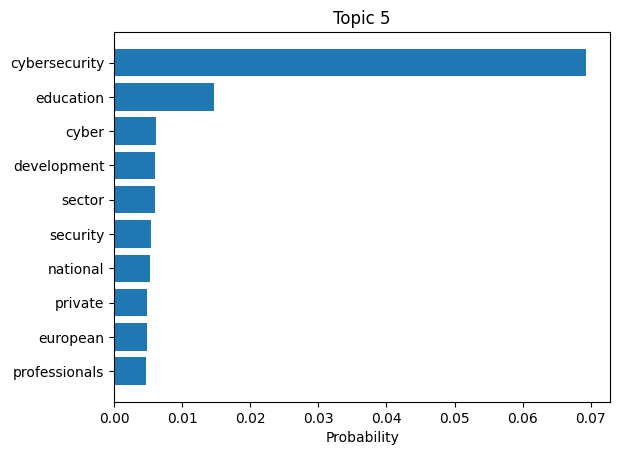

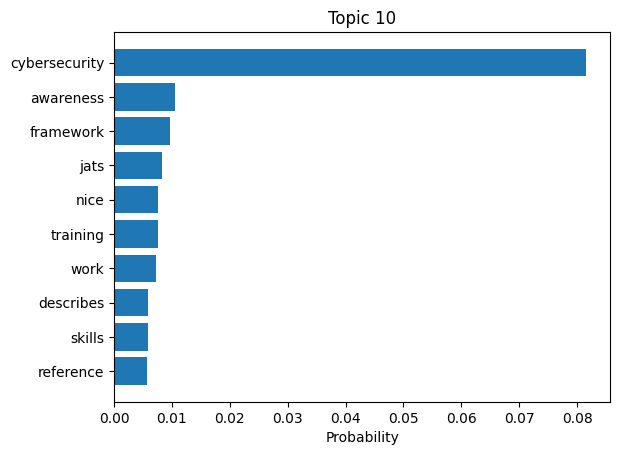

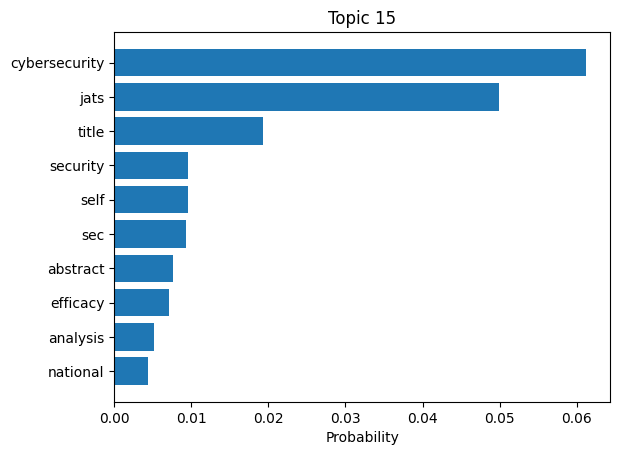

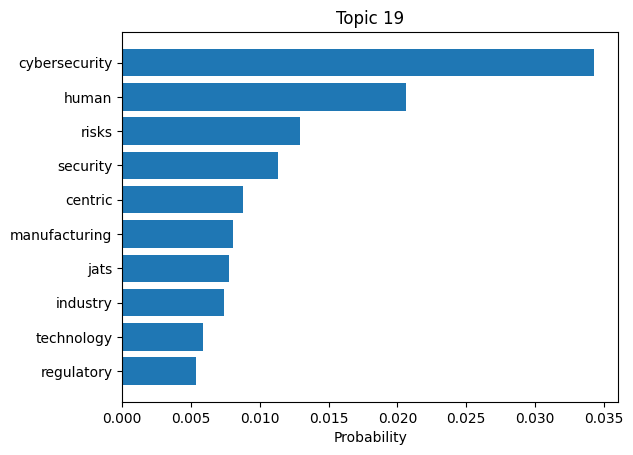

In [11]:
plot_topic(lda_20, 5)
plot_topic(lda_20, 10)
plot_topic(lda_20, 15)
plot_topic(lda_20, 19)

## Task 4

Based on the top keywords, I assigned labels to several topics. Topic 5 appears related to network security, Topic 10 appears related to cyber attacks and threat detection, Topic 15 appears related to privacy and data protection, and Topic 20 appears related to machine learning in cybersecurity. The most distinct topics were the ones with highly specific technical keywords, especially those related to attacks or privacy. Some topics overlapped in general cybersecurity terms such as systems, security, and network, which is expected because many cybersecurity articles discuss related issues. Overall, the top keywords aligned with my expectations because the dataset focused on cybersecurity and the discovered topics reflected common themes in that field.

## Task 5 Reflection

This assignment went well overall because I was able to load the dataset, preprocess the text, and run LDA topic models successfully. One challenge was making sure the preprocessing step removed unhelpful words so the topics made sense, and I also ran into a tokenizer issue in Colab that needed an extra NLTK download. Topic modeling could be useful in my future work because it can help identify patterns in large groups of text, such as cybersecurity reports, support tickets, incident logs, or research articles.